# Empirical study notebook

In [1]:
from explainer import estimate_interventional_probability_tabular, PrototypeTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from utils import *
from XAI_metrics import *
from xgboost import XGBClassifier

RANDOM_SEED = 42

In [2]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")

# COMPAS dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas_df = pd.read_csv(url)

# US Census Dataset
acs_income = fetch_acs_income(as_frame=True)
X_acs = acs_income.data
y_acs = acs_income.target

# Adult income dataset
adult_data = fetch_adult(as_frame=True)
X_adult = adult_data.data
y_adult = adult_data.target

## Loan dataset

In [3]:
X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model1.fit(X_train_processed_loan, y_train_loan)
y_predict_loan = loan_model1.predict(X_test_processed_loan)

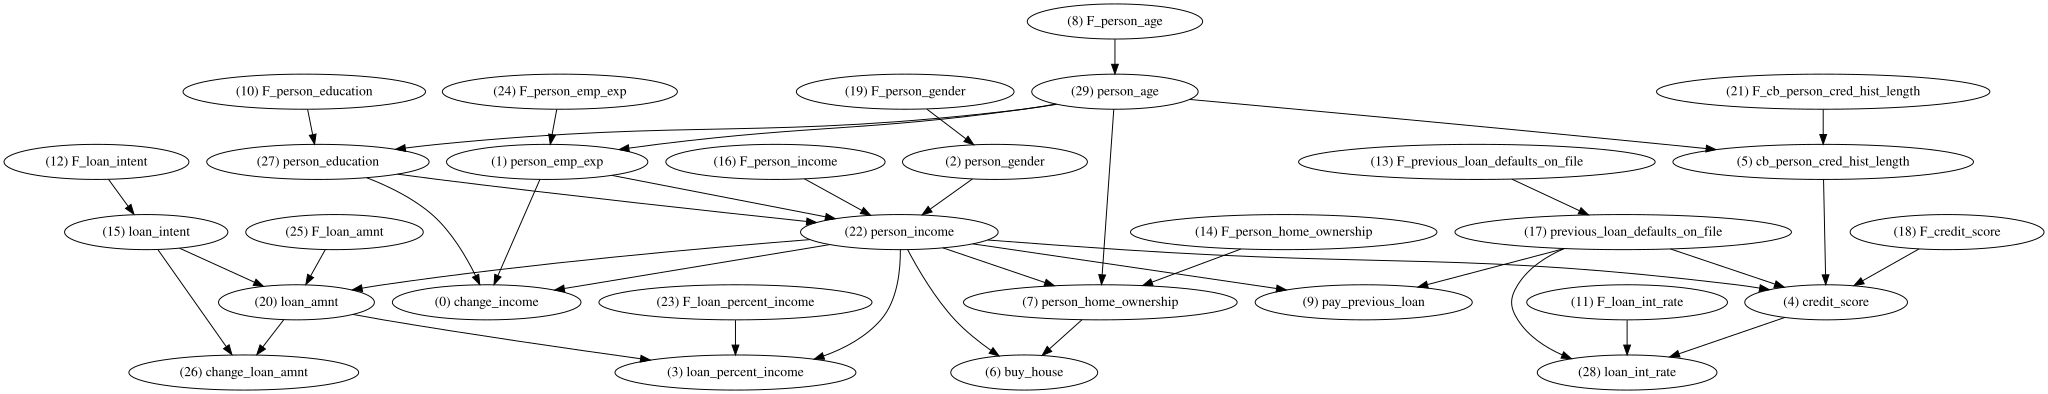

In [8]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_causal = CausalModel(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

In [9]:
utility_matrix = np.array([[-1, 0], [-1, 0], [-1, 0], [-1, 0]])
prototype_explainer = PrototypeTabularExplainer(loan_features, loan_model1, loan_actions, loan_causal, utility_matrix, X_train_processed_loan, cognitive=())
x_instance = X_test_processed_loan.iloc[[0]]
prototype_explainer.explain_instance(x_instance)

In [10]:
prototype_explainer.explanations

[{'features': {'person_home_ownership'},
  'utility score': np.float64(-2.931639507533831),
  'information score': np.float64(0.5803430820263524)},
 {'features': {'loan_int_rate', 'person_home_ownership'},
  'utility score': np.float64(-2.97742427496843),
  'information score': np.float64(0.5684511135698432)},
 {'features': {'loan_int_rate'},
  'utility score': np.float64(-2.9802830989485893),
  'information score': np.float64(0.5676859400308479)},
 {'features': {'loan_percent_income', 'person_home_ownership'},
  'utility score': np.float64(-3.2833785262872572),
  'information score': np.float64(0.47011031221400723)},
 {'features': {'loan_percent_income'},
  'utility score': np.float64(-3.291037151092739),
  'information score': np.float64(0.46718355245622445)},
 {'features': {'loan_int_rate',
   'loan_percent_income',
   'person_home_ownership'},
  'utility score': np.float64(-3.3351901317268347),
  'information score': np.float64(0.44981333212418384)},
 {'features': {'loan_int_rate',

## Synthetic dataset

## New dataset